Benchmark Configuration:
  Number of qubits: 8
  Number of random states: 10
  Number of Pauli operators: 65,536
  Total expectation values to compute: 655,360

🚀 Starting benchmark...

Step 1: Generating all Pauli operators...
  Generated 65,536 Pauli operators

Step 2: Generating random quantum states...
  Generated 10 random 8-qubit states

Method 1: Statevector.expectation_value()
  States   1- 10: avg 1.149s per state (57,019 expectations/sec)

Statevector Method Results:
  Total time: 11.49s
  Average time per state: 1.149s ± 0.047s
  Throughput: 57,019 expectations/sec
  Total expectations computed: 655,360

Method 2: StatevectorEstimator (Primitive)
  States   1- 10: avg 56.323s per state (1,164 expectations/sec)

Estimator Method Results:
  Total time: 563.23s
  Average time per state: 56.323s ± 1.650s
  Throughput: 1,164 expectations/sec
  Total expectations computed: 655,360

Verification: Comparing Results from Both Methods
Maximum difference between methods: 0.00e+00
✓ Res

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/pauli_benchmark_results.png'

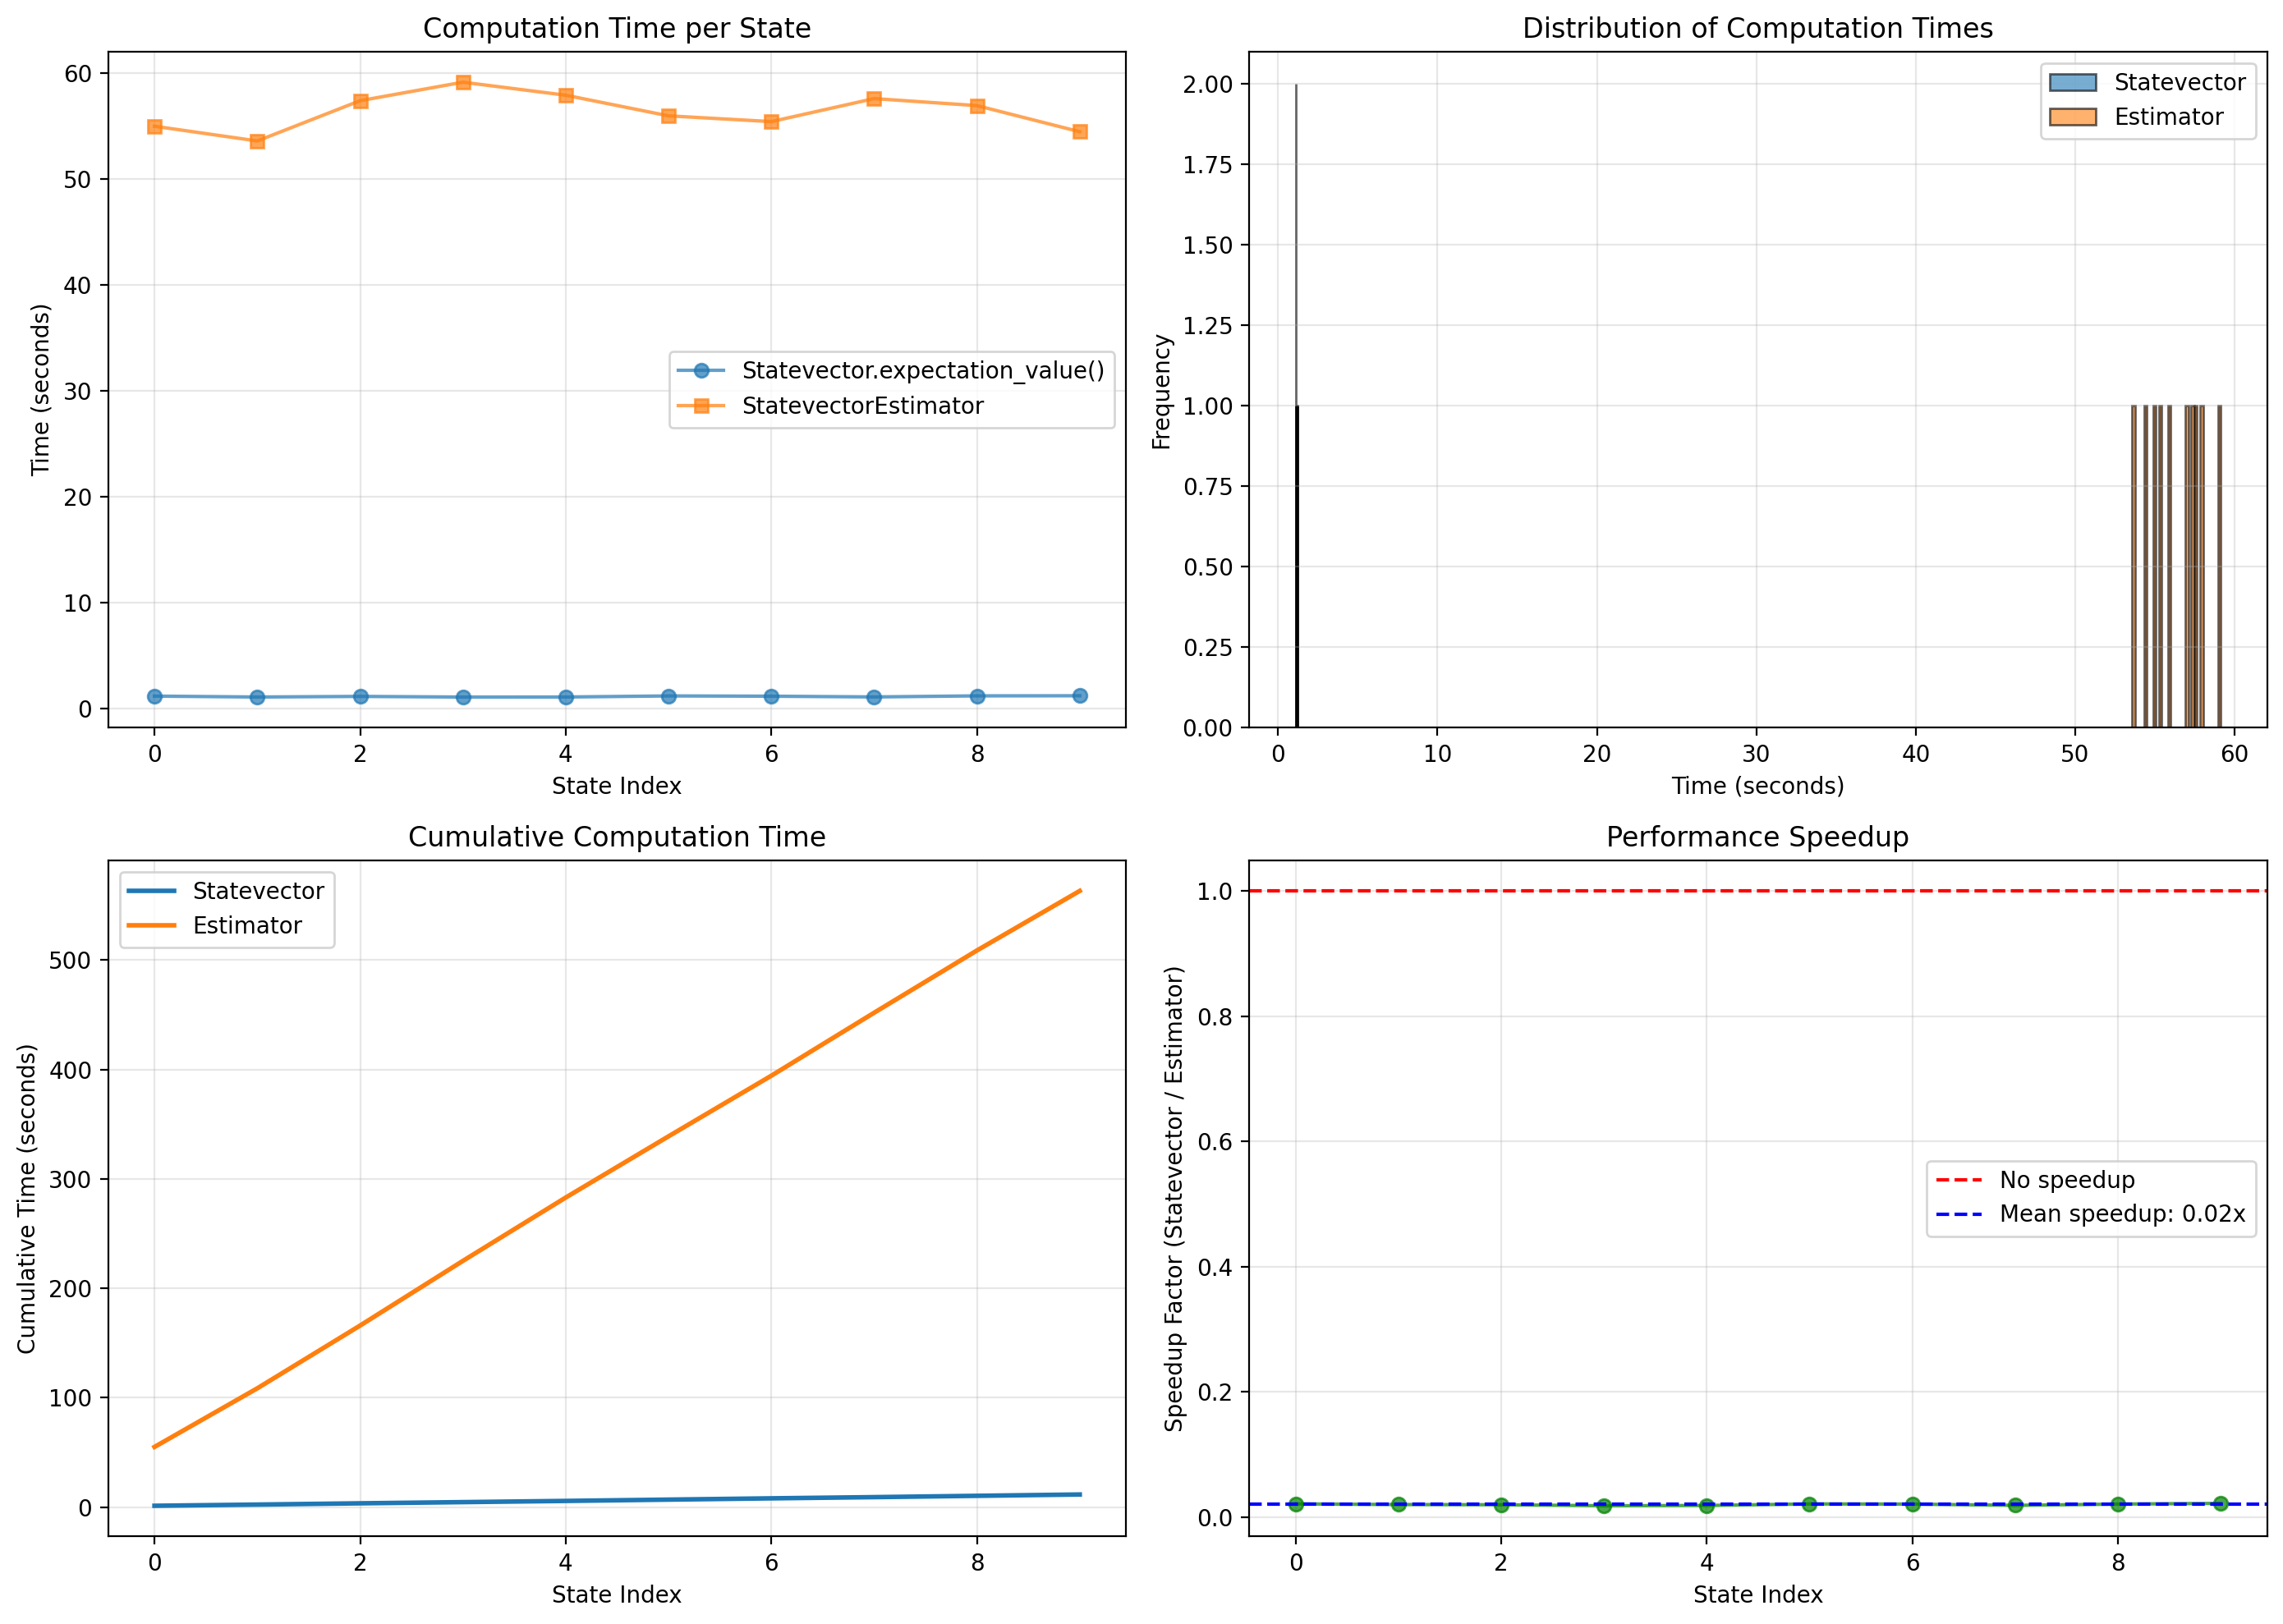

In [2]:
"""
Benchmark comparing Qiskit Estimator vs Statevector.expectation_value
for computing expectation values of all Pauli operators on random quantum states.

This script generates 100 random 10-qubit pure states and evaluates the 
expectation value of all 4^10 = 1,048,576 Pauli operators for each state.
"""

import numpy as np
import time
from itertools import product
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, random_statevector, Pauli, SparsePauliOp
from qiskit.primitives import StatevectorEstimator
import matplotlib.pyplot as plt

# Configuration
NUM_QUBITS = 8
NUM_STATES = 10
NUM_PAULIS = 4 ** NUM_QUBITS  # 1,048,576 for 10 qubits

print(f"Benchmark Configuration:")
print(f"  Number of qubits: {NUM_QUBITS}")
print(f"  Number of random states: {NUM_STATES}")
print(f"  Number of Pauli operators: {NUM_PAULIS:,}")
print(f"  Total expectation values to compute: {NUM_STATES * NUM_PAULIS:,}")
print("=" * 70)


def generate_all_pauli_strings(n_qubits):
    """
    Generate all possible Pauli strings for n qubits.
    Returns a list of Pauli string representations.
    
    For n qubits, there are 4^n Pauli operators (I, X, Y, Z for each qubit).
    """
    pauli_basis = ['I', 'X', 'Y', 'Z']
    
    # Generate all combinations
    for pauli_tuple in product(pauli_basis, repeat=n_qubits):
        yield ''.join(pauli_tuple)


def generate_random_state_circuit(n_qubits):
    """
    Generate a quantum circuit that prepares a random pure state.
    Uses random unitary gates to create the state from |0...0>.
    """
    circuit = QuantumCircuit(n_qubits)
    
    # Apply random single-qubit rotations
    for qubit in range(n_qubits):
        circuit.rx(np.random.uniform(0, 2*np.pi), qubit)
        circuit.ry(np.random.uniform(0, 2*np.pi), qubit)
        circuit.rz(np.random.uniform(0, 2*np.pi), qubit)
    
    # Apply random entangling gates
    for _ in range(n_qubits):
        control = np.random.randint(0, n_qubits)
        target = np.random.randint(0, n_qubits)
        if control != target:
            circuit.cx(control, target)
            circuit.rz(np.random.uniform(0, 2*np.pi), target)
    
    return circuit


def benchmark_statevector_method(states, pauli_strings):
    """
    Benchmark using Statevector.expectation_value() method.
    This computes expectation values directly from the statevector.
    """
    print("\n" + "=" * 70)
    print("Method 1: Statevector.expectation_value()")
    print("=" * 70)
    
    times_per_state = []
    
    for state_idx, state in enumerate(states):
        start_time = time.time()
        
        expectations = []
        for pauli_str in pauli_strings:
            pauli_op = Pauli(pauli_str)
            exp_val = state.expectation_value(pauli_op).real
            expectations.append(exp_val)
        
        elapsed = time.time() - start_time
        times_per_state.append(elapsed)
        
        if (state_idx + 1) % 10 == 0:
            avg_time = np.mean(times_per_state[-10:])
            print(f"  States {state_idx-8:3d}-{state_idx+1:3d}: "
                  f"avg {avg_time:.3f}s per state "
                  f"({NUM_PAULIS/avg_time:,.0f} expectations/sec)")
    
    total_time = sum(times_per_state)
    avg_time = np.mean(times_per_state)
    std_time = np.std(times_per_state)
    
    print(f"\nStatevector Method Results:")
    print(f"  Total time: {total_time:.2f}s")
    print(f"  Average time per state: {avg_time:.3f}s ± {std_time:.3f}s")
    print(f"  Throughput: {NUM_PAULIS/avg_time:,.0f} expectations/sec")
    print(f"  Total expectations computed: {NUM_STATES * NUM_PAULIS:,}")
    
    return times_per_state, expectations[:10]  # Return sample for verification


def benchmark_estimator_method(circuits, pauli_strings):
    """
    Benchmark using StatevectorEstimator primitive.
    This is the modern Qiskit approach for computing expectation values.
    """
    print("\n" + "=" * 70)
    print("Method 2: StatevectorEstimator (Primitive)")
    print("=" * 70)
    
    estimator = StatevectorEstimator()
    times_per_state = []
    
    # Convert all Pauli strings to SparsePauliOp objects
    # We'll batch these for efficiency
    pauli_ops = [SparsePauliOp(pauli_str) for pauli_str in pauli_strings]
    
    for state_idx, circuit in enumerate(circuits):
        start_time = time.time()
        
        # Run estimator for all observables at once
        # Create a pub (Primitive Unified Block) with circuit and all observables
        job = estimator.run([(circuit, pauli_ops)])
        result = job.result()
        expectations = result[0].data.evs
        
        elapsed = time.time() - start_time
        times_per_state.append(elapsed)
        
        if (state_idx + 1) % 10 == 0:
            avg_time = np.mean(times_per_state[-10:])
            print(f"  States {state_idx-8:3d}-{state_idx+1:3d}: "
                  f"avg {avg_time:.3f}s per state "
                  f"({NUM_PAULIS/avg_time:,.0f} expectations/sec)")
    
    total_time = sum(times_per_state)
    avg_time = np.mean(times_per_state)
    std_time = np.std(times_per_state)
    
    print(f"\nEstimator Method Results:")
    print(f"  Total time: {total_time:.2f}s")
    print(f"  Average time per state: {avg_time:.3f}s ± {std_time:.3f}s")
    print(f"  Throughput: {NUM_PAULIS/avg_time:,.0f} expectations/sec")
    print(f"  Total expectations computed: {NUM_STATES * NUM_PAULIS:,}")
    
    return times_per_state, expectations[:10]  # Return sample for verification


def plot_results(times_statevector, times_estimator):
    """
    Create visualization of benchmark results.
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Plot 1: Time per state for both methods
    ax = axes[0, 0]
    ax.plot(times_statevector, 'o-', label='Statevector.expectation_value()', alpha=0.7)
    ax.plot(times_estimator, 's-', label='StatevectorEstimator', alpha=0.7)
    ax.set_xlabel('State Index')
    ax.set_ylabel('Time (seconds)')
    ax.set_title('Computation Time per State')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 2: Histogram of times
    ax = axes[0, 1]
    ax.hist(times_statevector, bins=30, alpha=0.6, label='Statevector', edgecolor='black')
    ax.hist(times_estimator, bins=30, alpha=0.6, label='Estimator', edgecolor='black')
    ax.set_xlabel('Time (seconds)')
    ax.set_ylabel('Frequency')
    ax.set_title('Distribution of Computation Times')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 3: Cumulative time
    ax = axes[1, 0]
    ax.plot(np.cumsum(times_statevector), label='Statevector', linewidth=2)
    ax.plot(np.cumsum(times_estimator), label='Estimator', linewidth=2)
    ax.set_xlabel('State Index')
    ax.set_ylabel('Cumulative Time (seconds)')
    ax.set_title('Cumulative Computation Time')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 4: Speedup factor
    ax = axes[1, 1]
    speedup = np.array(times_statevector) / np.array(times_estimator)
    ax.plot(speedup, 'o-', color='green', alpha=0.7)
    ax.axhline(y=1, color='r', linestyle='--', label='No speedup')
    ax.axhline(y=np.mean(speedup), color='b', linestyle='--', 
               label=f'Mean speedup: {np.mean(speedup):.2f}x')
    ax.set_xlabel('State Index')
    ax.set_ylabel('Speedup Factor (Statevector / Estimator)')
    ax.set_title('Performance Speedup')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('/mnt/user-data/outputs/pauli_benchmark_results.png', dpi=150, bbox_inches='tight')
    print(f"\n📊 Plot saved to outputs/pauli_benchmark_results.png")
    
    return fig


def verify_consistency(sample_sv, sample_est, tolerance=1e-10):
    """
    Verify that both methods give the same results.
    """
    print("\n" + "=" * 70)
    print("Verification: Comparing Results from Both Methods")
    print("=" * 70)
    
    max_diff = np.max(np.abs(np.array(sample_sv) - np.array(sample_est)))
    print(f"Maximum difference between methods: {max_diff:.2e}")
    
    if max_diff < tolerance:
        print("✓ Results are consistent! Both methods produce identical values.")
    else:
        print(f"⚠ Warning: Difference exceeds tolerance ({tolerance})")
        print("Sample values from Statevector:", sample_sv[:5])
        print("Sample values from Estimator:  ", sample_est[:5])


def main():
    """
    Main benchmark execution.
    """
    print("\n🚀 Starting benchmark...\n")
    
    # Step 1: Generate all Pauli strings
    print("Step 1: Generating all Pauli operators...")
    pauli_strings = list(generate_all_pauli_strings(NUM_QUBITS))
    print(f"  Generated {len(pauli_strings):,} Pauli operators")
    
    # Step 2: Generate random states
    print("\nStep 2: Generating random quantum states...")
    circuits = [generate_random_state_circuit(NUM_QUBITS) for _ in range(NUM_STATES)]
    states = [Statevector.from_instruction(circ) for circ in circuits]
    print(f"  Generated {len(states)} random {NUM_QUBITS}-qubit states")
    
    # Step 3: Benchmark Statevector method
    times_sv, sample_sv = benchmark_statevector_method(states, pauli_strings)
    
    # Step 4: Benchmark Estimator method
    times_est, sample_est = benchmark_estimator_method(circuits, pauli_strings)
    
    # Step 5: Compare results
    verify_consistency(sample_sv, sample_est)
    
    # Step 6: Summary statistics
    print("\n" + "=" * 70)
    print("SUMMARY")
    print("=" * 70)
    avg_sv = np.mean(times_sv)
    avg_est = np.mean(times_est)
    speedup = avg_sv / avg_est
    
    print(f"\nStatevector method:")
    print(f"  Average: {avg_sv:.3f}s ± {np.std(times_sv):.3f}s per state")
    print(f"  Total:   {sum(times_sv):.2f}s for all {NUM_STATES} states")
    
    print(f"\nEstimator method:")
    print(f"  Average: {avg_est:.3f}s ± {np.std(times_est):.3f}s per state")
    print(f"  Total:   {sum(times_est):.2f}s for all {NUM_STATES} states")
    
    print(f"\n{'🚀 Estimator is FASTER' if speedup > 1 else '🐌 Statevector is FASTER'}")
    print(f"  Speedup factor: {speedup:.2f}x")
    print(f"  Time saved: {sum(times_sv) - sum(times_est):.2f}s "
          f"({100*(1-1/speedup):.1f}% faster)")
    
    # Step 7: Create visualization
    print("\nStep 7: Creating visualization...")
    plot_results(times_sv, times_est)
    
    print("\n✓ Benchmark complete!")
    print("=" * 70)


if __name__ == "__main__":
    main()